In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

from keras.models import Sequential
from keras.layers import Activation, Dense, Dropout, GRU
from keras import layers
from keras.layers import LayerNormalization
from keras.optimizers import Adam, RMSprop

%matplotlib inline

In [95]:
# df = pd.read_csv('btc_max_ohlc_yfinance.csv')
df = pd.read_csv('btc_change_rate.csv')

df.columns = df.columns.str.lower()
df['date'] = pd.to_datetime(df['date'])

df.sort_values("date", axis=0, ascending=True, inplace=True)

# 篩選2021-07-01之後的資料
df = df[df['date'] >= '2021-07-01'].copy()

df = df.set_index('date')
print(df)
# df.drop(['unix', 'symbol', 'tradecount'], axis=1, inplace=True)

            change_rate
date                   
2021-07-01    -4.178182
2021-07-02     1.035617
2021-07-03     2.404782
2021-07-04     1.794907
2021-07-05    -4.359837
...                 ...
2026-05-08     0.221399
2026-05-09     0.594386
2026-05-10     1.826454
2026-05-11    -0.500067
2026-05-12    -2.169012

[1777 rows x 1 columns]


In [96]:
# increasing rate data

data_returns = df.iloc[:, 0]

windows = []
target = []
length = 10

for i in range(len(data_returns) - length):
    x = data_returns.iloc[i : i+length]
    y = data_returns.iloc[i+length]
    windows.append(x)
    target.append(y)

windows = np.array(windows)
target = np.array(target).reshape(-1, 1)

sc = StandardScaler()
windows_scaled = sc.fit_transform(windows)
target_scaled = sc.fit_transform(target)

windows_scaled = windows_scaled.reshape((len(windows_scaled), length, 1))

# 4. 切分 80% 訓練集與 20% 測試集
num_train = int(0.80 * windows_scaled.shape[0])

X_train = windows_scaled[:num_train, :, :]
X_test = windows_scaled[num_train:, :, :]
y_train = target_scaled[:num_train, :]
y_test = target_scaled[num_train:, :]

print(f"X_train shape: {X_train.shape}") # 預期輸出: (樣本數, 10, 1)
print(f"y_train shape: {y_train.shape}") # 預期輸出: (樣本數, 1)

X_train shape: (1413, 10, 1)
y_train shape: (1413, 1)


In [44]:
# price data

# 取close欄位，index = 3
data = df.iloc[:, 3]
windows = []
target = []
length = 20

# 建立長度為 10 的window slide
for i in range(len(data)-length):
    x = data[i:i+length]
    y = data[i+length]
    windows.append(x)
    target.append(y)

windows = np.array(windows)
target = np.array(target)
target = target.reshape(-1, 1)

# 正規化資料到 0~1 之間
sc = MinMaxScaler()
windows_scaled = sc.fit_transform(windows)
target_scaled = sc.fit_transform(target)

# Reshape 符合 GRU 輸入格式 (batch_size, window_size, input_dim)
windows_scaled = windows_scaled.reshape((len(windows_scaled), length, 1))

# 切分 80% 訓練集與 20% 測試集
num_train = int(0.80 * windows_scaled.shape[0])

X_train = windows_scaled[:num_train, :, :]
X_test = windows_scaled[num_train:, :, :]
y_train = target_scaled[:num_train, :]
y_test = target_scaled[num_train:, :]

IndexError: single positional indexer is out-of-bounds

In [90]:
# 定義建立模型的函數
def build_gru_model(input_data, output_size, neurons, activ_func, dropout, loss, optimizer):
    model = Sequential()
    model.add(GRU(neurons, input_shape=(input_data.shape[1], input_data.shape[2])))
    model.add(LayerNormalization())
    model.add(Dropout(dropout))
    model.add(Dense(units=output_size))
    model.add(Activation(activ_func))
    model.compile(loss=loss, optimizer=optimizer, metrics=['mae'])
    return model

# 設定超參數
gru_neurons = 100
loss = 'mse'
dropout = 0.2
optimizer = 'adam'
activ_func = 'linear'

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.4270 - mae: 0.8738 - val_loss: 0.9803 - val_mae: 0.7143
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.3047 - mae: 0.8220 - val_loss: 0.9460 - val_mae: 0.7047
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.2886 - mae: 0.8219 - val_loss: 0.9674 - val_mae: 0.6998
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.2382 - mae: 0.8018 - val_loss: 1.0369 - val_mae: 0.7524
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.2500 - mae: 0.8143 - val_loss: 0.9852 - val_mae: 0.7127
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.2507 - mae: 0.7862 - val_loss: 0.9427 - val_mae: 0.6939
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.2318 - mae: 0.7992 - val_loss: 0.9300 - val_mae: 0.6841
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.2091 - mae: 0.7851 - val_loss: 0.9460 - val_mae: 0.7176
Epoch 9/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.1923 - mae: 0.

In [97]:
TIME_STEPS = X_train.shape[1]
FEATURES = X_train.shape[2]
OUTPUT_SIZE = 1

def build_tuner_gru_model(hp):
    model = Sequential()

    # GRU neuron: 50 ~ 200，+=50
    hp_neurons = hp.Int('gru_neurons', min_value=50, max_value=200, step=50)
    model.add(GRU(units=hp_neurons, input_shape=(TIME_STEPS, FEATURES)))

    # Dropout:  0.1 ~ 0.5
    hp_dropout = hp.Float('dropout', min_value=0.1, max_value=0.5, step=0.1)
    model.add(Dropout(rate=hp_dropout))

    model.add(Dense(units=OUTPUT_SIZE))

    # activation function
    hp_activ = hp.Choice('activ_func', values=['linear', 'relu'])
    model.add(Activation(hp_activ))

    # lr, optimizer
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    hp_optimizer = hp.Choice('optimizer', values=['adam', 'rmsprop'])

    if hp_optimizer == 'adam':
        optimizer = Adam(learning_rate=hp_learning_rate)
    else:
        optimizer = RMSprop(learning_rate=hp_learning_rate)

    model.compile(loss='mse', optimizer=optimizer, metrics=['mae'])

    return model

In [98]:
epochs = 100
batch_size = 32

# 建立並訓練模型 (切分 10% 做驗證集)
model = build_gru_model(X_train, output_size=1, neurons=gru_neurons, activ_func=activ_func,
                        dropout=dropout, loss=loss, optimizer=optimizer)

out = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=1, validation_split=0.1)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1.4214 - mae: 0.8602 - val_loss: 0.9262 - val_mae: 0.7008
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.4028 - mae: 0.8719 - val_loss: 0.9181 - val_mae: 0.6962
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.3677 - mae: 0.8474 - val_loss: 0.9643 - val_mae: 0.7054
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.2877 - mae: 0.8200 - val_loss: 0.9525 - val_mae: 0.7190
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.3117 - mae: 0.8246 - val_loss: 0.9266 - val_mae: 0.6919
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.2443 - mae: 0.8028 - val_loss: 1.0074 - val_mae: 0.7323
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.2397 - mae: 0.8015 - val_loss: 0.9261 - val_mae: 0.6904
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.2134 - mae: 0.7877 - val_loss: 1.0016 - val_mae: 0.7258
Epoch 9/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.1786 - mae: 0.

In [99]:
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_11 (GRU)                    │ (None, 100)            │        30,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_6           │ (None, 100)            │           200 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           101 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,605 (365.65 KB)

 Trainable params: 31,201 (121.88 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62,404 (243.77 KB)

In [100]:
# 進行預測
pred = model.predict(X_test)

# 將預測結果與實際結果逆轉換回真實價格區間
pred_transformed = sc.inverse_transform(pred)
y_test_transformed = sc.inverse_transform(y_test)

# 計算各項誤差指標 (MSE, RMSE, MAPE, MAE)
mse = mean_squared_error(pred, y_test)
print("MSE:", mse)
rmse = np.sqrt(mse)
print("RMSE:", rmse)
mape = mean_absolute_percentage_error(pred, y_test)
print("MAPE:", mape)
mae = mean_absolute_error(pred, y_test)
print("MAE:", mae)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
MSE: 0.6671680460333269
RMSE: 0.8168035541262825
MAPE: 22.052589669516845
MAE: 0.5858423927452368


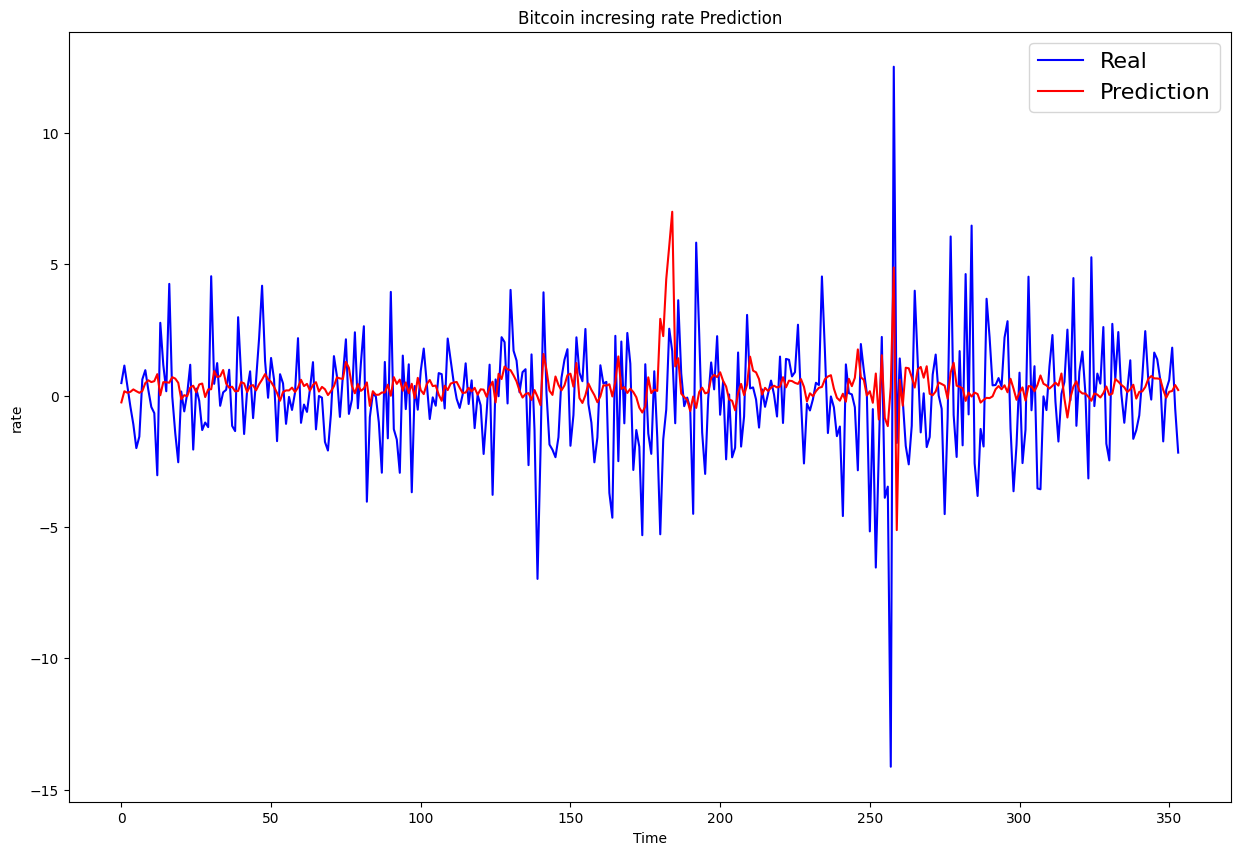

In [101]:
# increasing rate and prediction rate plot
plt.figure(figsize=(15,10))
plt.plot(y_test_transformed, color='blue', label='Real')
plt.plot(pred_transformed, color='red', label='Prediction')
plt.title('Bitcoin incresing rate Prediction')
plt.ylabel('rate')
plt.xlabel('Time')
plt.legend(loc='best', fontsize=16)
plt.show()

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])


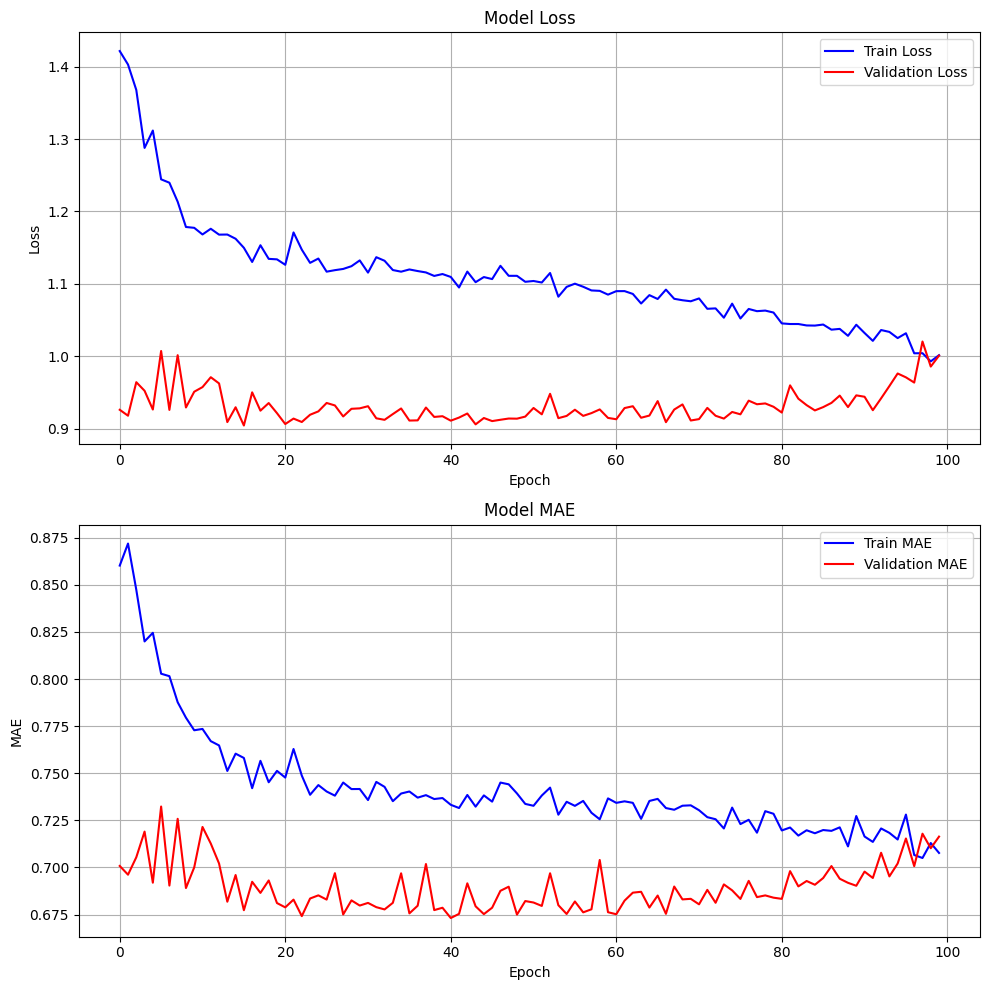

In [102]:
history = out
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# loss
ax1.plot(history.history['loss'], label='Train Loss', color='blue')
ax1.plot(history.history['val_loss'], label='Validation Loss', color='red')
ax1.set_title('Model Loss')
ax1.set_ylabel('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(True)

print(history.history.keys())

# accuracy
ax2.plot(history.history['mae'], label='Train MAE', color='blue')
ax2.plot(history.history['val_mae'], label='Validation MAE', color='red')
ax2.set_title('Model MAE')
ax2.set_ylabel('MAE')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

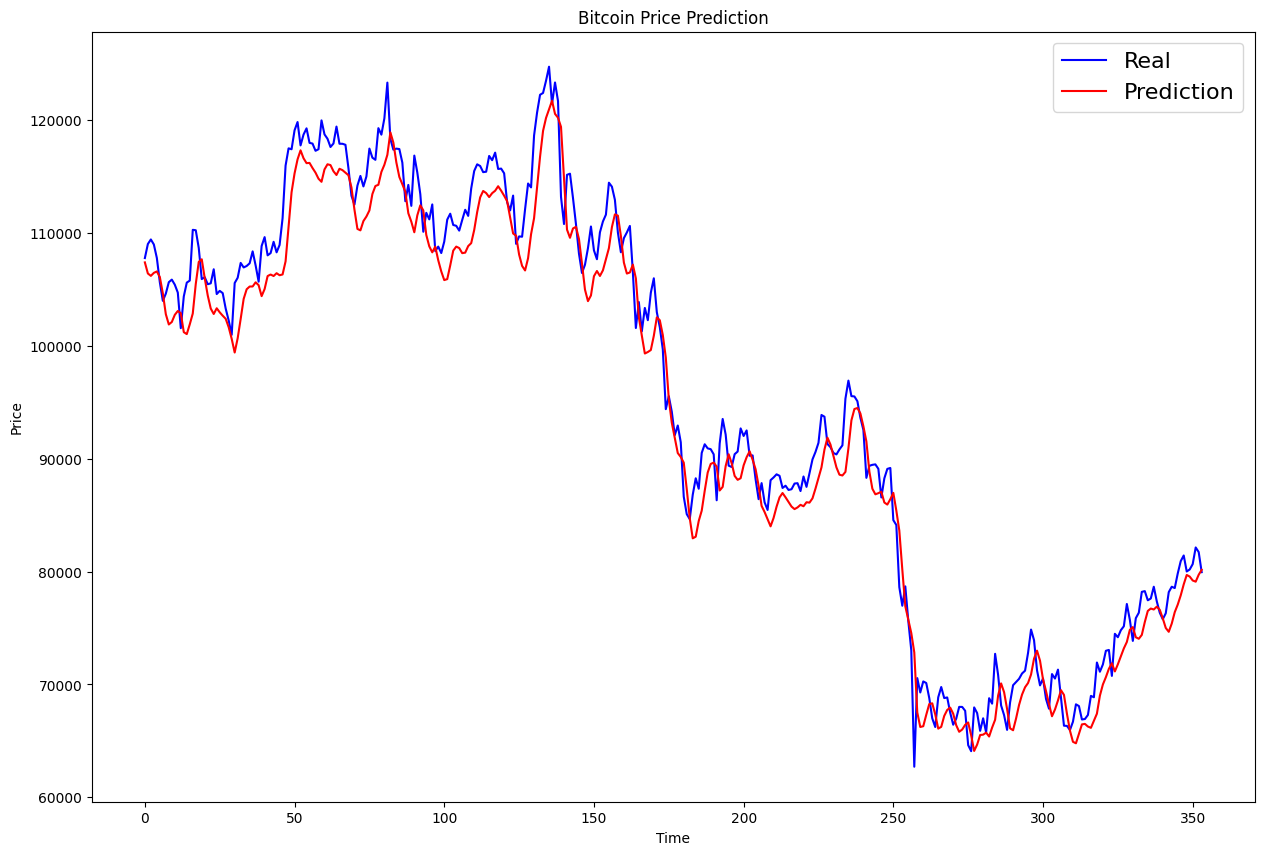

In [ ]:
# 繪製真實價格與預測價格的走勢圖
plt.figure(figsize=(15,10))
plt.plot(y_test_transformed, color='blue', label='Real')
plt.plot(pred_transformed, color='red', label='Prediction')
plt.title('Bitcoin Price Prediction')
plt.ylabel('Price')
plt.xlabel('Time')
plt.legend(loc='best', fontsize=16)
plt.show()